In [1]:
# /// script
# requires-python = ">=3.10"
# dependencies = [
#     "matplotlib",
#     "numpy",
#     "scikit-image",
#     "scipy",
#     "tifffile",
#     "imagecodecs",
#     "pandas",
#     "seaborn",
#     "bobiac_tools @ git+https://github.com/bobiac/bobiac-tools.git"
# ]
# ///

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import skimage
import tifffile
from bobiac_tools import overlay_labels

In [3]:
# define file paths
image_path = Path(
    "../../_static/images/quant/02_nested_measurements/images/F01_837.tif"
)
mask_cell_path = Path(
    "../../_static/images/quant/02_nested_measurements/masks/F01_837w1.TIF"
)
mask_nucleus_path = Path(
    "../../_static/images/quant/02_nested_measurements/masks/F01_837w2.TIF"
)
segmentation_spots_path = Path(
    "../../_static/images/quant/02_nested_measurements/spot_lists/F01_837_spots.csv"
)

# load images and masks
image = tifffile.imread(image_path)
image_nuclear = image[0]
image_spots = image[2]

mask_cell = tifffile.imread(mask_cell_path)
mask_nucleus = tifffile.imread(mask_nucleus_path)

# remove boundary objects
mask_cell = skimage.segmentation.clear_border(mask_cell)
mask_nucleus = skimage.segmentation.clear_border(mask_nucleus)

# load segmented spots
df_spots = pd.read_csv(segmentation_spots_path)

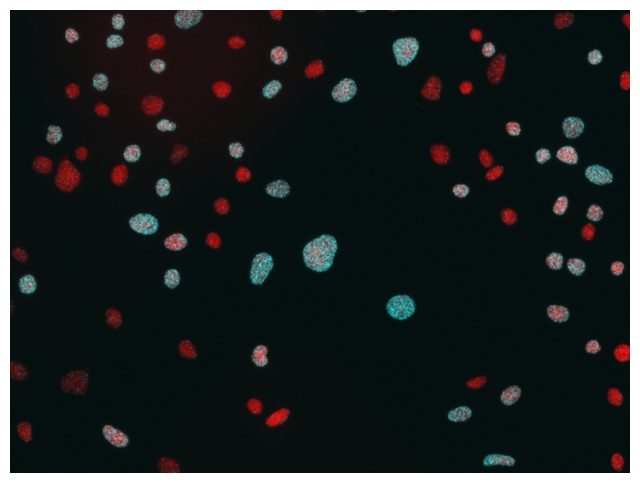

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [4]:
overlay_labels(image=[image_nuclear, image_spots])

In [5]:
print(df_spots[["y", "x"]])

         y     x
0       92   136
1       37   125
2       86   140
3       43   121
4       52   154
...    ...   ...
1173  1036  1161
1174  1026  1187
1175  1019  1197
1176  1010   509
1177  1010   472

[1178 rows x 2 columns]


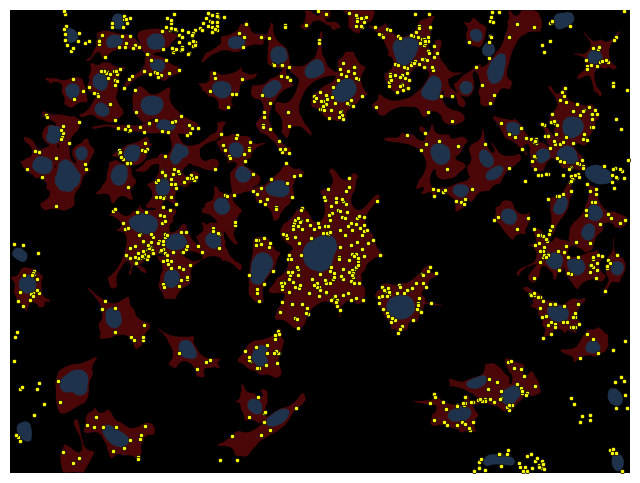

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [6]:
overlay_labels(
    label_mask=[mask_cell, mask_nucleus], coordinates=df_spots[["y", "x"]].to_numpy()
)

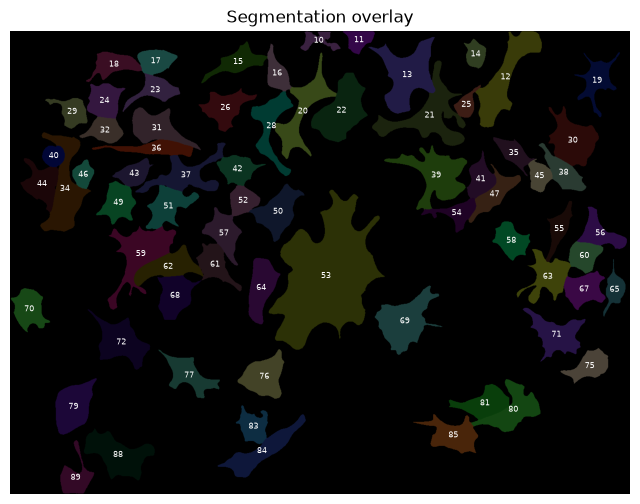

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [7]:
overlay_labels(label_mask=mask_cell)

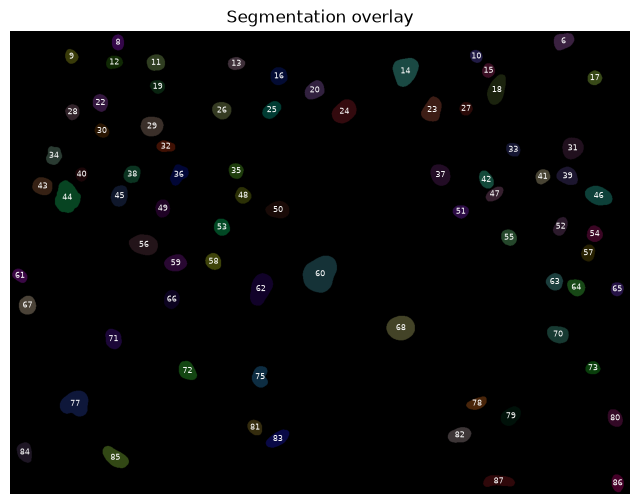

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [8]:
overlay_labels(label_mask=mask_nucleus)

In [9]:
properties = ["area", "label"]
props = skimage.measure.regionprops_table(mask_cell, properties=properties)

df_cell = pd.DataFrame(props)
print(df_cell)

       area  label
0    1835.0     10
1    2252.0     11
2   11083.0     12
3   11811.0     13
4    2201.0     14
..      ...    ...
65   3711.0     83
66   6932.0     84
67   6111.0     85
68   9146.0     88
69   3786.0     89

[70 rows x 2 columns]


In [10]:
properties = ["area", "intensity_mean", "label"]
props = skimage.measure.regionprops_table(
    mask_nucleus, intensity_image=image_nuclear, properties=properties
)

df_nuc = pd.DataFrame(props)
print(df_nuc)

      area  intensity_mean  label
0   1377.0     1190.348584      6
1    796.0     1762.503769      8
2    744.0     2053.278226      9
3    643.0     2353.867807     10
4   1222.0     1984.824877     11
..     ...             ...    ...
72  1372.0     2598.682945     83
73  1219.0     1351.519278     84
74  1872.0     1978.978098     85
75   868.0     2060.660138     86
76  1472.0     1160.914402     87

[77 rows x 3 columns]


In [11]:
df_nuc["image_id"] = image_path.stem
print(df_nuc)

      area  intensity_mean  label image_id
0   1377.0     1190.348584      6  F01_837
1    796.0     1762.503769      8  F01_837
2    744.0     2053.278226      9  F01_837
3    643.0     2353.867807     10  F01_837
4   1222.0     1984.824877     11  F01_837
..     ...             ...    ...      ...
72  1372.0     2598.682945     83  F01_837
73  1219.0     1351.519278     84  F01_837
74  1872.0     1978.978098     85  F01_837
75   868.0     2060.660138     86  F01_837
76  1472.0     1160.914402     87  F01_837

[77 rows x 4 columns]


<Axes: xlabel='intensity_mean', ylabel='Count'>

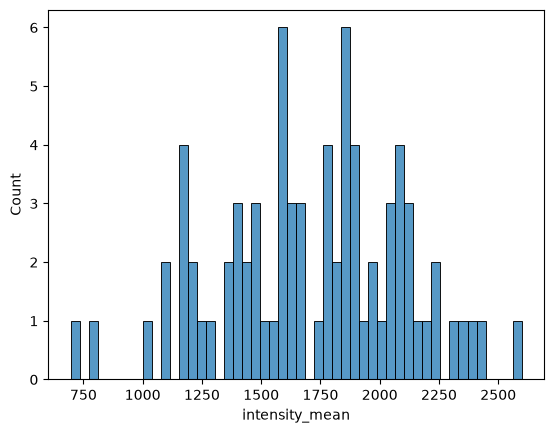

In [12]:
sns.histplot(
    data=df_nuc,
    x="intensity_mean",
    bins=50,
)

In [13]:
df_nuc["expression"] = pd.cut(
    df_nuc["intensity_mean"], bins=[0, 1700, np.inf], labels=["off", "on"]
)
print(df_nuc["expression"].unique())

['off', 'on']
Categories (2, str): ['off' < 'on']


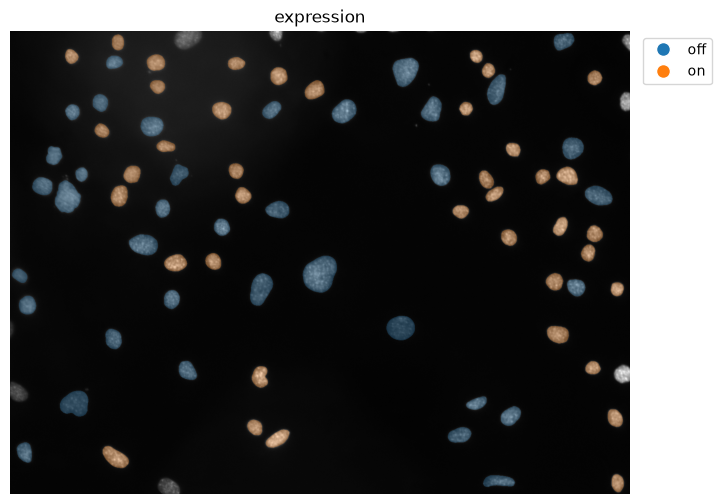

(<Figure size 800x800 with 1 Axes>, <Axes: title={'center': 'expression'}>)

In [14]:
overlay_labels(
    image=image_nuclear,
    label_mask=mask_nucleus,
    df=df_nuc,
    id_col="label",
    measurement_col="expression",
)

In [15]:
print(df_nuc)

      area  intensity_mean  label image_id expression
0   1377.0     1190.348584      6  F01_837        off
1    796.0     1762.503769      8  F01_837         on
2    744.0     2053.278226      9  F01_837         on
3    643.0     2353.867807     10  F01_837         on
4   1222.0     1984.824877     11  F01_837         on
..     ...             ...    ...      ...        ...
72  1372.0     2598.682945     83  F01_837         on
73  1219.0     1351.519278     84  F01_837        off
74  1872.0     1978.978098     85  F01_837         on
75   868.0     2060.660138     86  F01_837         on
76  1472.0     1160.914402     87  F01_837        off

[77 rows x 5 columns]


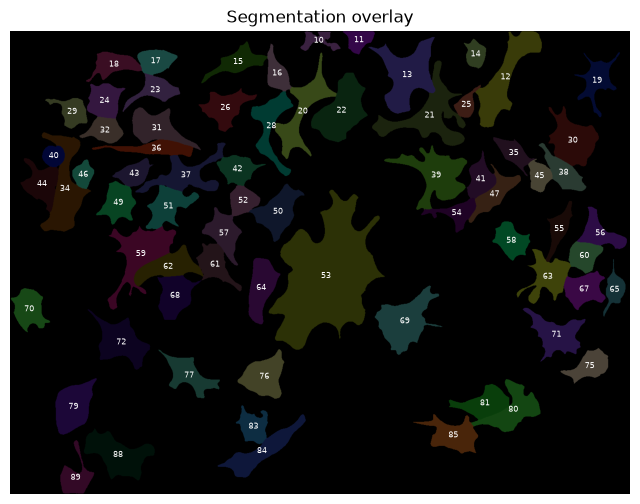

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [16]:
overlay_labels(label_mask=mask_cell)

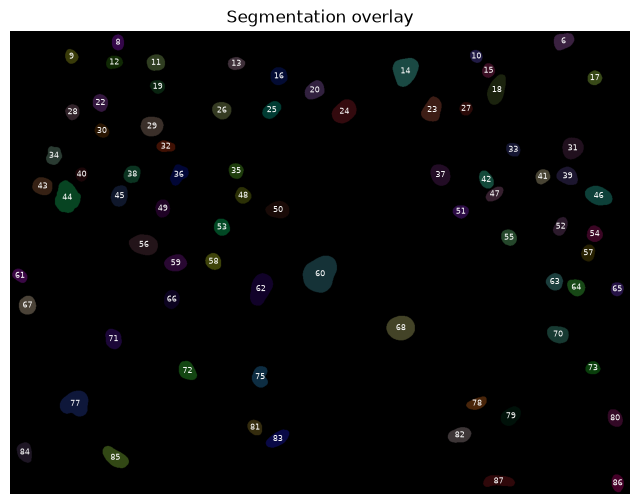

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [17]:
overlay_labels(label_mask=mask_nucleus)

In [18]:
properties = ["intensity_mean", "label"]
labels = skimage.measure.regionprops_table(
    mask_nucleus, intensity_image=mask_cell, properties=properties
)

df_merge = pd.DataFrame(labels)
df_merge = df_merge.rename({"intensity_mean": "label_cell"}, axis=1)
print(df_merge)

    label_cell  label
0          0.0      6
1          0.0      8
2          0.0      9
3         14.0     10
4         17.0     11
..         ...    ...
72        84.0     83
73         0.0     84
74        88.0     85
75         0.0     86
76         0.0     87

[77 rows x 2 columns]


In [19]:
df_nuc = df_nuc.merge(df_merge, on="label", how="left")
print(df_nuc)

      area  intensity_mean  label image_id expression  label_cell
0   1377.0     1190.348584      6  F01_837        off         0.0
1    796.0     1762.503769      8  F01_837         on         0.0
2    744.0     2053.278226      9  F01_837         on         0.0
3    643.0     2353.867807     10  F01_837         on        14.0
4   1222.0     1984.824877     11  F01_837         on        17.0
..     ...             ...    ...      ...        ...         ...
72  1372.0     2598.682945     83  F01_837         on        84.0
73  1219.0     1351.519278     84  F01_837        off         0.0
74  1872.0     1978.978098     85  F01_837         on        88.0
75   868.0     2060.660138     86  F01_837         on         0.0
76  1472.0     1160.914402     87  F01_837        off         0.0

[77 rows x 6 columns]


In [20]:
mapping = df_nuc.loc[df_nuc["label_cell"] != 0].drop_duplicates(
    "label_cell", keep=False
)[["label_cell", "expression"]]
mapping

,label_cell,expression
3,14.0,on
4,17.0,on
5,18.0,off
6,15.0,on
7,13.0,off
...,...,...
68,80.0,off
70,83.0,on
71,85.0,off
72,84.0,on


In [21]:
df_cell = df_cell.merge(
    mapping, left_on="label", right_on="label_cell", how="inner"
).drop(columns="label_cell")
print(df_cell)

       area  label expression
0   11083.0     12        off
1   11811.0     13        off
2    2201.0     14         on
3    4385.0     15         on
4    3136.0     16         on
..      ...    ...        ...
62   5343.0     81        off
63   3711.0     83         on
64   6932.0     84         on
65   6111.0     85        off
66   9146.0     88         on

[67 rows x 3 columns]


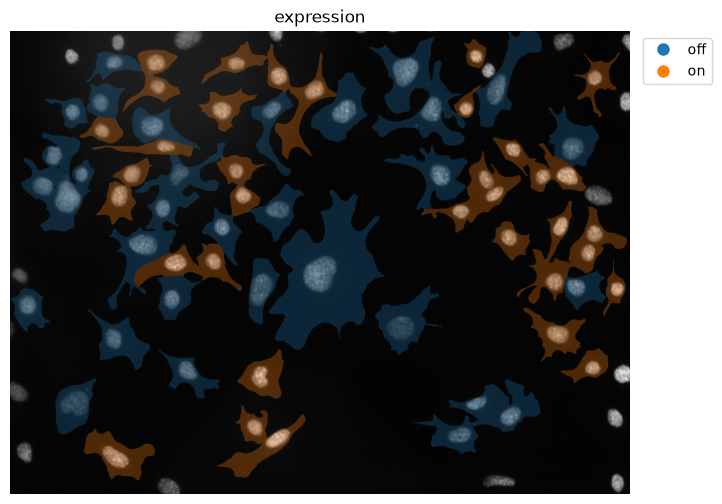

(<Figure size 800x800 with 1 Axes>, <Axes: title={'center': 'expression'}>)

In [22]:
overlay_labels(
    image=image_nuclear,
    label_mask=mask_cell,
    df=df_cell,
    id_col="label",
    measurement_col="expression",
)

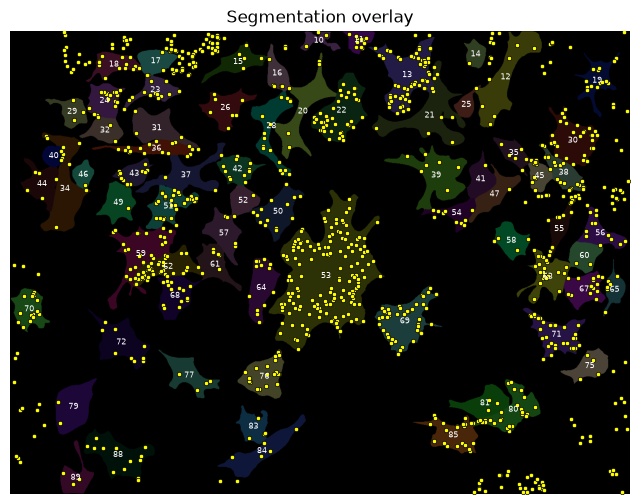

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [23]:
overlay_labels(label_mask=mask_cell, coordinates=df_spots[["y", "x"]].to_numpy())

In [24]:
df_spots["label_cell"] = mask_cell[df_spots["y"].astype(int), df_spots["x"].astype(int)]
print(df_spots["label_cell"].unique())

[ 0 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 28 29 30 31 32 34
 35 36 37 38 39 40 41 42 43 44 45 46 47 49 50 51 52 53 54 55 56 57 58 59
 60 61 62 63 64 65 67 68 69 70 71 72 75 76 77 79 80 81 83 84 85 88 89]


<Axes: xlabel='label_cell', ylabel='Count'>

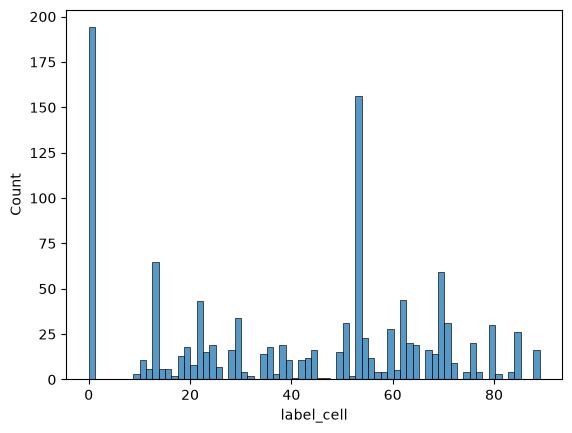

In [25]:
sns.histplot(data=df_spots, x="label_cell", bins=len(df_spots["label_cell"].unique()))

In [26]:
df_spots = df_spots.loc[df_spots["label_cell"] != 0]
print(df_spots)

      channel     y    x  label_cell
98          1     2  691          10
99          1    33  664          10
100         1    10  710          10
101         1    19  791          11
102         1    16  799          11
...       ...   ...  ...         ...
1143        1  1003  288          88
1144        1  1008  288          88
1145        1  1006  154          89
1146        1  1017  140          89
1147        1   992  119          89

[984 rows x 4 columns]


In [27]:
mapping = df_spots["label_cell"].value_counts().reset_index()
print(mapping)

    label_cell  count
0           53    156
1           13     65
2           62     44
3           69     44
4           22     43
..         ...    ...
65          25      1
66          41      1
67          46      1
68          47      1
69          49      1

[70 rows x 2 columns]


In [28]:
df_cell = df_cell.merge(
    mapping, left_on="label", right_on="label_cell", how="inner"
).drop(columns="label_cell")
print(df_cell)

       area  label expression  count
0   11083.0     12        off      6
1   11811.0     13        off     65
2    2201.0     14         on      1
3    4385.0     15         on      5
4    3136.0     16         on      6
..      ...    ...        ...    ...
62   5343.0     81        off      3
63   3711.0     83         on      4
64   6932.0     84         on      5
65   6111.0     85        off     21
66   9146.0     88         on     13

[67 rows x 4 columns]


<Axes: xlabel='count', ylabel='Count'>

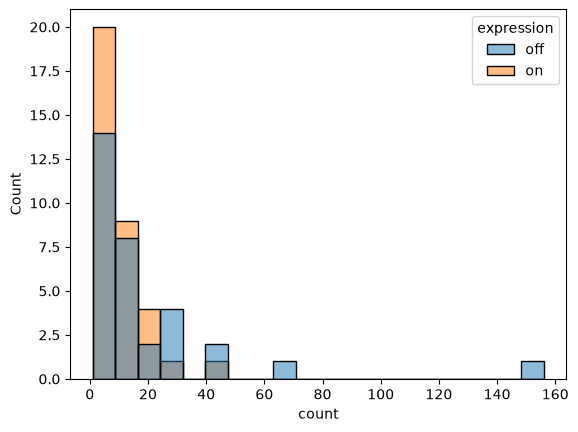

In [29]:
sns.histplot(
    data=df_cell,
    x="count",
    bins=20,
    hue="expression",
)

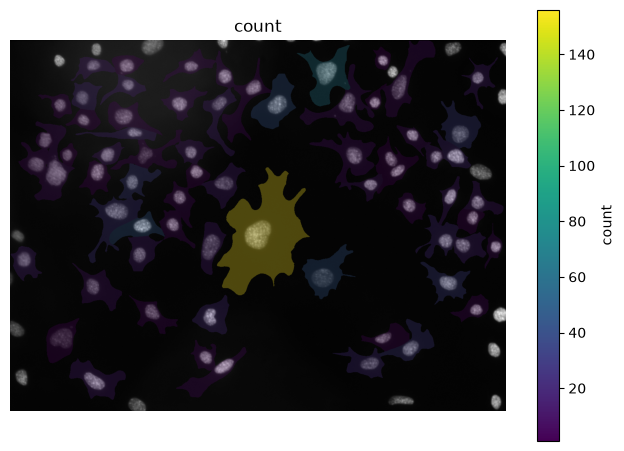

(<Figure size 800x800 with 2 Axes>, <Axes: title={'center': 'count'}>)

In [30]:
overlay_labels(
    image=image_nuclear,
    label_mask=mask_cell,
    df=df_cell,
    id_col="label",
    measurement_col="count",
)

In [31]:
df_cell["spot_count_norm"] = df_cell["count"] / df_cell["area"]
print(df_cell["spot_count_norm"])

0     0.000541
1     0.005503
2     0.000454
3     0.001140
4     0.001913
        ...   
62    0.000561
63    0.001078
64    0.000721
65    0.003436
66    0.001421
Name: spot_count_norm, Length: 67, dtype: float64


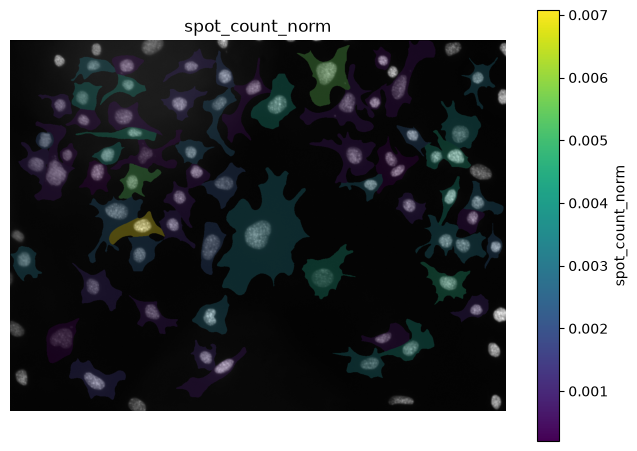

(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': 'spot_count_norm'}>)

In [32]:
overlay_labels(
    image=image_nuclear,
    label_mask=mask_cell,
    df=df_cell,
    id_col="label",
    measurement_col="spot_count_norm",
)

<Axes: xlabel='spot_count_norm', ylabel='Count'>

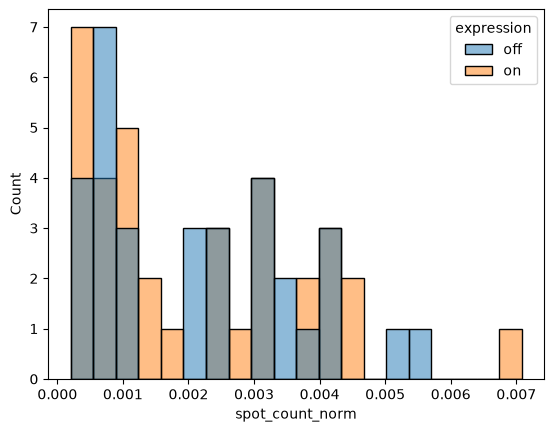

In [33]:
sns.histplot(data=df_cell, x="spot_count_norm", bins=20, hue="expression")

In [34]:
image_folder = Path("../../_static/images/quant/02_nested_measurements/images/")
mask_folder = Path("../../_static/images/quant/02_nested_measurements/masks/")
spot_folder = Path("../../_static/images/quant/02_nested_measurements/spot_lists/")

image_paths = sorted(image_folder.glob("*.tif"))

list_df = []

for image_path in image_paths:
    image_id = image_path.stem  # e.g. F01_837

    # load multi-channel image and extract nuclear channel
    image = tifffile.imread(image_path)
    image_nuclear = image[0]

    # load masks and spot coordinates
    mask_cell = tifffile.imread(mask_folder / f"{image_id}w1.TIF")
    mask_nucleus = tifffile.imread(mask_folder / f"{image_id}w2.TIF")
    df_spots = pd.read_csv(spot_folder / f"{image_id}_spots.csv")

    # remove objects touching the border
    mask_cell = skimage.segmentation.clear_border(mask_cell)
    mask_nucleus = skimage.segmentation.clear_border(mask_nucleus)

    # --- cell dataframe ---
    df_cell = pd.DataFrame(
        skimage.measure.regionprops_table(mask_cell, properties=["area", "label"])
    )

    # --- nucleus dataframe: measure and classify expression ---
    df_nuc = pd.DataFrame(
        skimage.measure.regionprops_table(
            mask_nucleus,
            intensity_image=image_nuclear,
            properties=["area", "intensity_mean", "label"],
        )
    )
    df_nuc["image_id"] = image_id
    df_nuc["expression"] = pd.cut(
        df_nuc["intensity_mean"], bins=[0, 1700, np.inf], labels=["off", "on"]
    )

    # --- map each nucleus to the cell it sits in ---
    df_merge = pd.DataFrame(
        skimage.measure.regionprops_table(
            mask_nucleus,
            intensity_image=mask_cell,
            properties=["intensity_mean", "label"],
        )
    ).rename(columns={"intensity_mean": "label_cell"})

    df_nuc = df_nuc.merge(df_merge, on="label", how="left")

    mapping_expr = df_nuc[df_nuc["label_cell"] != 0].drop_duplicates(
        "label_cell", keep=False
    )[["label_cell", "expression"]]
    df_cell = df_cell.merge(
        mapping_expr, left_on="label", right_on="label_cell", how="inner"
    ).drop(columns="label_cell")

    # --- count spots per cell ---
    df_spots["label_cell"] = mask_cell[
        df_spots["y"].astype(int), df_spots["x"].astype(int)
    ]
    df_spots = df_spots.loc[df_spots["label_cell"] != 0]
    mapping_spots = df_spots["label_cell"].value_counts().reset_index()
    df_cell = df_cell.merge(
        mapping_spots, left_on="label", right_on="label_cell", how="inner"
    ).drop(columns="label_cell")
    df_cell["spot_count_norm"] = df_cell["count"] / df_cell["area"]

    df_cell["image_id"] = image_id
    list_df.append(df_cell)

df_full = pd.concat(list_df, ignore_index=True)

In [35]:
print(df_full)

       area  label expression  count  spot_count_norm image_id
0   11083.0     12        off      6         0.000541  F01_837
1   11811.0     13        off     65         0.005503  F01_837
2    2201.0     14         on      1         0.000454  F01_837
3    4385.0     15         on      5         0.001140  F01_837
4    3136.0     16         on      6         0.001913  F01_837
..      ...    ...        ...    ...              ...      ...
62   5343.0     81        off      3         0.000561  F01_837
63   3711.0     83         on      4         0.001078  F01_837
64   6932.0     84         on      5         0.000721  F01_837
65   6111.0     85        off     21         0.003436  F01_837
66   9146.0     88         on     13         0.001421  F01_837

[67 rows x 6 columns]


In [36]:
df_plot = (
    df_full.groupby(["expression", "image_id"])[["count", "spot_count_norm"]]
    .mean()
    .reset_index()
)
df_plot

,expression,image_id,count,spot_count_norm
0,off,F01_837,19.812500,0.002175
1,on,F01_837,9.514286,0.002099


(0.0, 20.327410714285715)

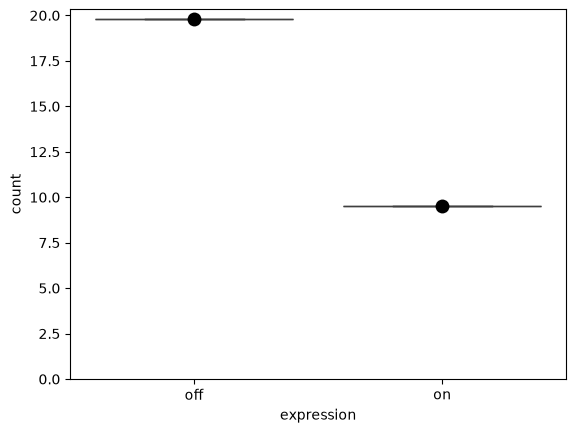

In [37]:
sns.boxplot(
    data=df_plot,
    x="expression",
    y="count",
)

sns.swarmplot(data=df_plot, x="expression", y="count", c="k", s=10)
plt.ylim(0)

(0.0, 0.0021783840977964435)

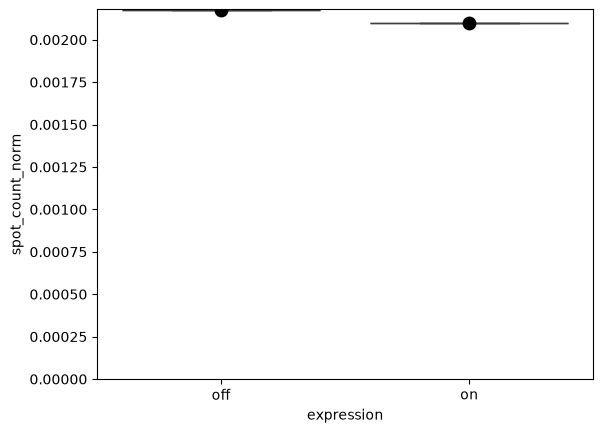

In [38]:
sns.boxplot(
    data=df_plot,
    x="expression",
    y="spot_count_norm",
)

sns.swarmplot(data=df_plot, x="expression", y="spot_count_norm", c="k", s=10)
plt.ylim(0)